In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from google.colab.patches import cv2_imshow

In [25]:
arquivo = files.upload()

Saving Tak_berjudul771_20260601223219.webp to Tak_berjudul771_20260601223219.webp


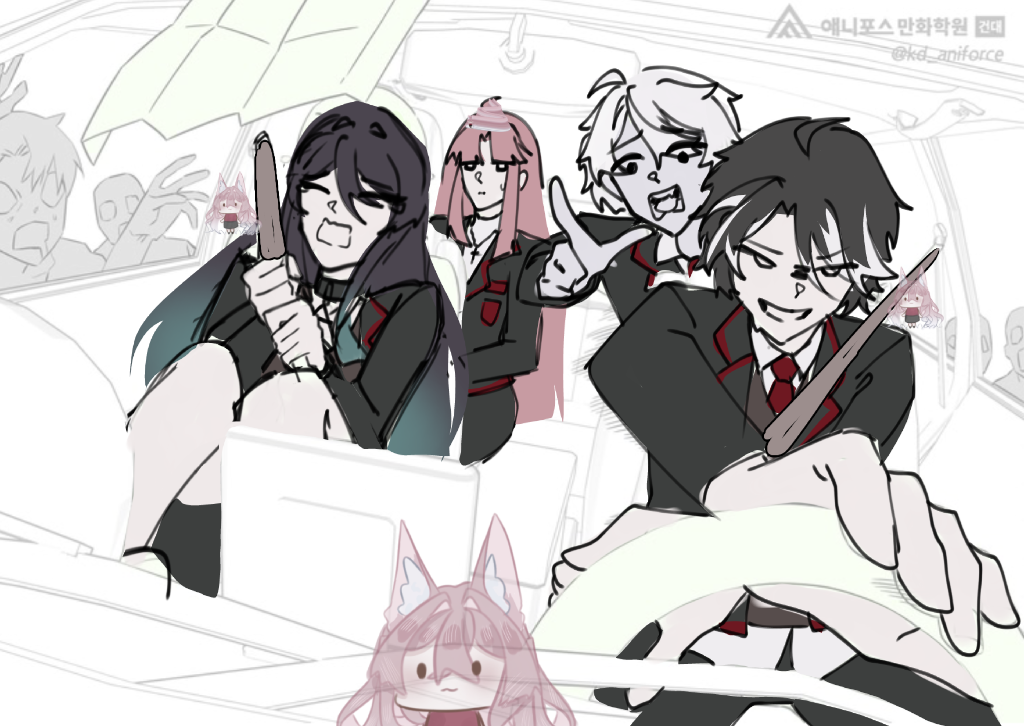

In [26]:
img = cv2.imread('Tak_berjudul771_20260601223219.webp')
cv2_imshow(img)

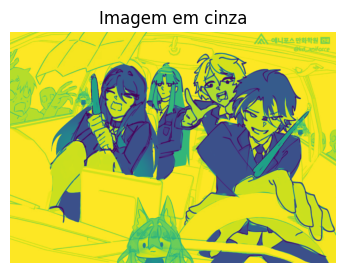

In [27]:
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(5,3))
plt.imshow(img_gray)
plt.title('Imagem em cinza')
plt.axis('off')

plt.show()

In [28]:
def quantizar_imagem(img, bits):
    niveis = 2 ** bits
    # Dividimos por 256 para normalizar entre 0 e 0.99...
    # Multiplicamos pela quantidade de níveis e arredondamos para baixo
    # Por fim, re-escalamos para a faixa de 0 a 255
    img_q = np.floor((img / 256.0) * niveis)
    img_q = np.uint8(img_q * (255.0 / (niveis - 1)))
    return img_q

In [29]:
img_1bit = quantizar_imagem(img_gray, 1) # 2 níveis
img_2bits = quantizar_imagem(img_gray, 2) # 4 níveis
img_4bits = quantizar_imagem(img_gray, 4) # 16 níveis
img_8bits = quantizar_imagem(img_gray, 8) # 256 níveis (igual a original)

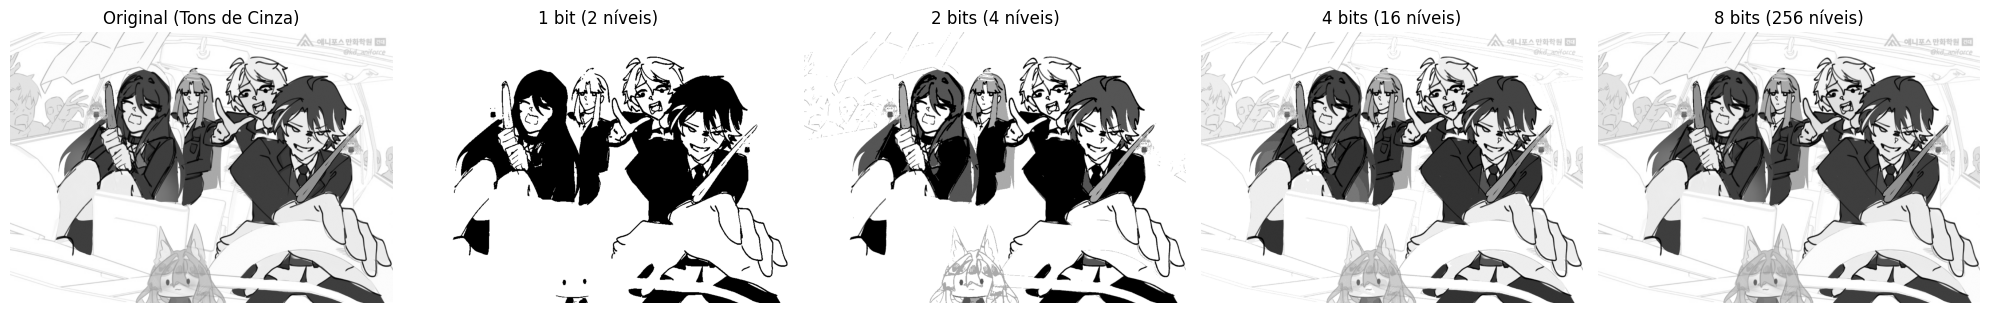

In [32]:
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

axs[0].imshow(img_gray, cmap='gray')
axs[0].set_title('Original (Tons de Cinza)')
axs[0].axis('off')

axs[1].imshow(img_1bit, cmap='gray')
axs[1].set_title('1 bit (2 níveis)')
axs[1].axis('off')

axs[2].imshow(img_2bits, cmap='gray')
axs[2].set_title('2 bits (4 níveis)')
axs[2].axis('off')

axs[3].imshow(img_4bits, cmap='gray')
axs[3].set_title('4 bits (16 níveis)')
axs[3].axis('off')

axs[4].imshow(img_8bits, cmap='gray')
axs[4].set_title('8 bits (256 níveis)')
axs[4].axis('off')

plt.tight_layout()
plt.savefig('quantização_de_bits.png', dpi=300, bbox_inches='tight')
plt.show()

### O que acontece com os detalhes e com as transições de intensidade da imagem à medida que reduzimos o número de bits?

A redução de bits diminui a quantidade de níveis de cinza disponíveis, criando manchas e contornos artificiais nas imagems